이미지 변환 및 저장 진행: 100%|██████████| 6/6 [00:04<00:00,  1.26it/s]
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

이미지 출력 중...


c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


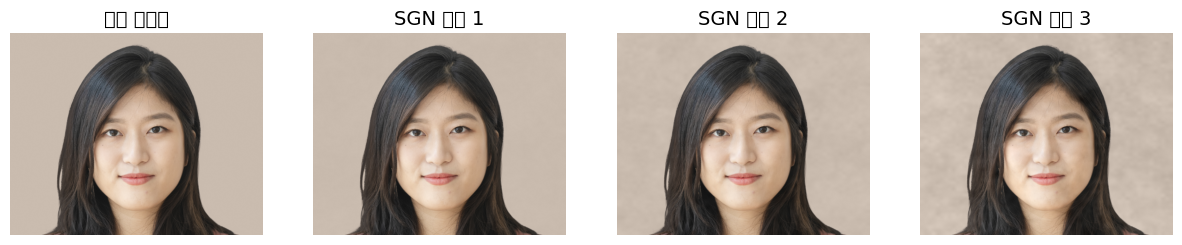

✅ 모든 이미지 출력 완료!
이미지 출력 중...


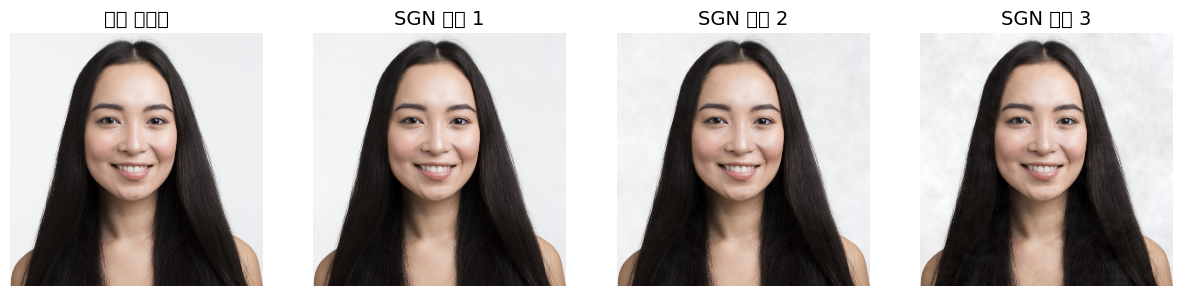

✅ 모든 이미지 출력 완료!
🎉 모든 StyleGAN 보호 이미지 저장 완료!


In [1]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

def generate_protective_noise(image_size, strength=0.03):
    """스타일GAN 기반 보호 노이즈 생성"""
    noise_layers = []
    for scale in [4, 8, 16, 32, 64]:
        if scale <= image_size[0] and scale <= image_size[1]:
            noise = torch.randn(1, 1, scale, scale)
            upsampled = torch.nn.functional.interpolate(
                noise, size=image_size, mode='bilinear', align_corners=False
            ).squeeze(0)
            noise_layers.append(upsampled)

    combined_noise = sum(noise_layers) / len(noise_layers)
    return combined_noise.expand(3, -1, -1) * strength

def protect_image(image_path, output_base, noise_strength):
    """이미지에 StyleGAN 기반 보호 노이즈 적용 및 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img)
    noise = generate_protective_noise((img_tensor.shape[1], img_tensor.shape[2]), strength=noise_strength)
    protected_img = img_tensor + noise
    protected_img = torch.clamp(protected_img, 0, 1)
    protected_pil = transforms.ToPILImage()(protected_img)
    output_path = f"{output_base}_SGN.jpg"
    protected_pil.save(output_path)
    return protected_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    print("이미지 출력 중...")
    fig, axes = plt.subplots(1, len(protected_list) + 1, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")
    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 보호 {i+1}", fontsize=14)
        axes[i + 1].axis("off")
    plt.show()
    print("✅ 모든 이미지 출력 완료!")

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.01, 0.03, 0.05)):
    """입력 폴더의 모든 이미지에 StyleGAN 보호 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="이미지 변환 및 저장 진행") as pbar:
        for img_path in image_paths:
            img_name, _ = os.path.splitext(os.path.basename(img_path))
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_strength in noise_levels:
                output_base = os.path.join(output_dir, f"{img_name}_{int(noise_strength*100)}")
                protected_pil = protect_image(img_path, output_base, noise_strength)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    # 변환이 모두 끝난 후 이미지 출력
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, "SGN")
    print("🎉 모든 StyleGAN 보호 이미지 저장 완료!")

# 실행
process_images()

In [13]:
!pip install torch
!pip install numpy
!pip install matplotlib
!pip install torchvision
!pip install tqdm
!pip install --upgrade ipywidgets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


...


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached ipywidgets-8.1.5-py3-none-any.whl.metadata (2.3 kB)
  Using cached widgetsnbextension-4.0.13-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.13-py3-none-any.whl.metadata (4.1 kB)
Using cached ipywidgets-8.1.5-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.13-py3-none-any.whl (214 kB)
Using cached widgetsnbextension-4.0.13-py3-none-any.whl (2.3 MB)



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
pip show numpy


Name: numpy
Version: 2.2.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are
 met:

     * Redistributions of source code must retain the above copyright
        notice, this list of conditions and the following disclaimer.

     * Redistributions in binary form must reproduce the above
        copyright notice, this list of conditions and the following
        disclaimer in the documentation and/or other materials provided
        with the distribution.

     * Neither the name of the NumPy Developers nor the names of any
        contributors may be used to endorse or promote products derived
        from this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED

In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm

# 이미지 저장 경로 설정
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

def protect_image(image_path, output_base, noise_level, model_name):
    """이미지 보호 노이즈 적용 후 저장 (노이즈 모델 제외)"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    # 노이즈 모델은 외부에서 정의됨
    noisy_pil = transforms.ToPILImage()(img_tensor.squeeze(0).cpu())

    output_path = os.path.join(output_dir, f"{output_base}_{int(noise_level*100)}_{model_name}.jpg")
    noisy_pil.save(output_path)
    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력 + 슬라이더 추가"""
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.subplots_adjust(bottom=0.25)  # 슬라이더 공간 확보
    
    # 첫 번째 이미지를 기본값으로 설정
    img_display = ax.imshow(protected_list[0])
    ax.set_title(f"{model_name} 노이즈 1단계", fontsize=14)
    ax.axis("off")
    
    # 슬라이더 추가
    ax_slider = plt.axes([0.25, 0.1, 0.5, 0.03])  # 위치 지정
    slider = Slider(ax_slider, "노이즈 단계", 1, len(protected_list), valinit=1, valstep=1)

    # 슬라이더 변경 이벤트 처리
    def update(val):
        index = int(slider.val) - 1
        img_display.set_data(protected_list[index])
        ax.set_title(f"{model_name} 노이즈 {index + 1}단계", fontsize=14)
        fig.canvas.draw_idle()

    slider.on_changed(update)
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.01, 0.03, 0.05), model_name="Model"):
    """입력 폴더의 모든 이미지에 보호 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))
    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    protected_images_dict = {}
    original_images_dict = {}
    
    with tqdm(total=len(image_paths) * len(noise_levels), desc="이미지 변환 및 저장 진행") as pbar:
        for img_path in image_paths:
            img_name, _ = os.path.splitext(os.path.basename(img_path))
            protected_images = []
            original = Image.open(img_path).convert("RGB")
            original_images_dict[img_name] = original
            for noise_level in noise_levels:
                output_base = os.path.join(output_dir, img_name)
                protected_pil = protect_image(img_path, output_base, noise_level, model_name)
                protected_images.append(protected_pil)
                pbar.update(1)
            protected_images_dict[img_name] = protected_images
    
    # 변환이 모두 끝난 후 이미지 출력
    print("이미지 출력 중...")
    for img_name, protected_images in protected_images_dict.items():
        display_images(original_images_dict[img_name], protected_images, img_name, model_name)
    print(f"🎉 모든 {model_name} 보호 이미지 저장 완료!")

# 실행
process_images()


이미지 변환 및 저장 진행:   0%|          | 0/6 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\pycode\\AIFAKER\\Output\\Output\\001_1_Model.jpg'

In [ ]:
import time
import ipywidgets as widgets
from IPython.display import display

# 1️⃣ 기본 진행바 (IntProgress)
progress_bar1 = widgets.IntProgress(value=0, min=0, max=100, description="기본:", bar_style="info")

# 2️⃣ 원형 진행바 (FloatProgress)
progress_bar2 = widgets.FloatProgress(value=0, min=0, max=100, description="원형:", bar_style="warning")

# 3️⃣ 점 로딩 스타일 (HTML로 구현)
progress_text = widgets.HTML(value="<b>점 로딩 중:</b> ⏳")

# 4️⃣ 바 스타일이 변경되는 진행바
progress_bar3 = widgets.IntProgress(value=0, min=0, max=100, description="컬러바:", bar_style="success")

# 진행바 디스플레이
display(progress_bar1, progress_bar2, progress_text, progress_bar3)

# 진행 함수
def run_progress():
    for i in range(101):
        time.sleep(0.05)  # 딜레이 추가
        progress_bar1.value = i
        progress_bar2.value = i
        progress_bar3.value = i
        
        # 점 로딩 애니메이션 (3개 점이 순환)
        dots = "." * (i % 3 + 1)
        progress_text.value = f"<b>점 로딩 중:</b> ⏳{dots}"
    
    progress_text.value = "<b>✅ 로딩 완료!</b> 🎉"

# 실행
run_progress()


In [3]:
import time
from tqdm import tqdm

# ✅ 1️⃣ 기본 진행 바 (일반적인 스타일)
for i in tqdm(range(100), desc="🔵 기본 진행 바"):
    time.sleep(0.02)

# ✅ 2️⃣ ASCII 스타일 (기본 스타일보다 가볍고 단순한 바)
for i in tqdm(range(100), desc="🔲 ASCII 바", ascii=True):
    time.sleep(0.02)

# ✅ 3️⃣ 점진적 스타일 (점 차오름)
for i in tqdm(range(100), desc="⚪ 점진적 바", bar_format="{desc}: {percentage:3.0f}% ⚪{bar}⚪ {n_fmt}/{total_fmt} ETA: {remaining}"):
    time.sleep(0.02)

# ✅ 4️⃣ 짧은 바 (간결한 스타일)
for i in tqdm(range(100), desc="🔹 짧은 바", bar_format="{desc}: {percentage:3.0f}% |{bar}| ETA: {remaining}", ncols=50):
    time.sleep(0.02)

# ✅ 5️⃣ 색상 바 (`colour` 옵션 사용)
for i in tqdm(range(100), desc="🟢 초록색 바", colour="green"):
    time.sleep(0.02)

for i in tqdm(range(100), desc="🔴 빨간색 바", colour="red"):
    time.sleep(0.02)

for i in tqdm(range(100), desc="🟡 노란색 바", colour="yellow"):
    time.sleep(0.02)

# ✅ 6️⃣ 애니메이션 스타일 (점차적으로 올라가는 바)
for i in tqdm(range(100), desc="🌈 애니메이션 바", bar_format="{desc}: {percentage:3.0f}% [{bar}] ETA: {remaining}"):
    time.sleep(0.02)

# ✅ 7️⃣ 반전 바 (빈 공간이 점점 줄어드는 스타일)
for i in tqdm(range(100), desc="⬜ 반전 바", bar_format="{desc}: {percentage:3.0f}% {bar}|"):
    time.sleep(0.02)


🔲 ASCII 바: 100%|##########| 100/100 [00:02<00:00, 48.84it/s]
⚪ 점진적 바: 100% ⚪██████████⚪ 100/100 ETA: 00:00
🔹 짧은 바: 100% |████████████████████| ETA: 00:00
🟡 노란색 바: 100%|██████████| 100/100 [00:02<00:00, 48.78it/s]
🌈 애니메이션 바: 100% [██████████] ETA: 00:00
⬜ 반전 바: 100% ██████████|
